In [1]:
import warnings
warnings.filterwarnings('ignore')

(Tutorial_Get_metal_coordination)=
# get_metal_coordination

*Observing sparse metal-ligand proximity candidates.*

The descriptive method `metal_ligand_distance` with profile `smarts_metal_ligand` reproduces the pinned ProLIF 2.2.2 distance core at <=0.28 nm. It observes candidates and does not change ChemicalStates, certify a coordination bond, infer coordination number or compute energy.

:::{versionadded} 1.0.0
:::

:::{admonition} API documentation
:class: dropdown

See {func}`molsysmt.interactions.metal_coordination.get_metal_coordination` for arguments, outputs and explicit failures.
:::

## Basic usage

Controlled hydrated/amine zinc coordinates demonstrate variable counts and an evaluated empty frame. They are illustrative geometry rather than a minimized biological structure.

In [2]:
import numpy as np
import molsysmt as msm
from rdkit import Chem
molsys = msm.convert(Chem.MolFromSmiles('[Zn+2].O.N'), to_form='molsysmt.MolSys')
xyz = np.array([[[0,0,0],[.2,0,0],[0,.27,0]], [[0,0,0],[1,0,0],[0,1,0]], [[0,0,0],[.24,0,0],[0,.4,0]]])
molsys.structures.append(coordinates=msm.pyunitwizard.quantity(xyz, 'nm'))
analysis = msm.interactions.metal_coordination.get_metal_coordination(molsys, pbc=False)
print('Observations:', analysis.n_interactions, 'evaluated frames:', analysis.evaluated_structure_indices.tolist())

Observations: 3 evaluated frames: [0, 1, 2]


## Selecting atoms and structures

Internal keeps both actual participants; incident keeps either; between crosses disjoint sets. Frame numbers are indices, not IDs. Repeated nonconsecutive indices are evaluated once.

In [3]:
for mode, first, second in [('internal',[0,1],None), ('incident',[1],None), ('between',[1,2],[0])]:
    result = msm.interactions.metal_coordination.get_metal_coordination(molsys, selection=first, selection_2=second, selection_mode=mode, structure_indices=[2,0,2], pbc=False)
    print(mode, result.n_interactions, result.evaluated_structure_indices.tolist())
print('Empty frame:', analysis.query(structure_indices=[1]).n_interactions)
print('Zinc observations:', analysis.query(atom_indices=[0], mode='incident').n_interactions)

internal 2 [0, 2]
incident 2 [0, 2]
between 3 [0, 2]
Empty frame: 0
Zinc observations: 3


## Reading directed roles and geometry

Metal is always the first role, regardless of which atom selection supplied it. Distance values carry the negotiated stored unit.

{'interaction_type': 'metal_coordination_candidate', 'participants': [{'role': 'metal', 'atom_indices': array([0])}, {'role': 'ligand', 'atom_indices': array([1])}]}
{'distance': array([0.2 , 0.27, 0.24])} {'distance': 'nm'}


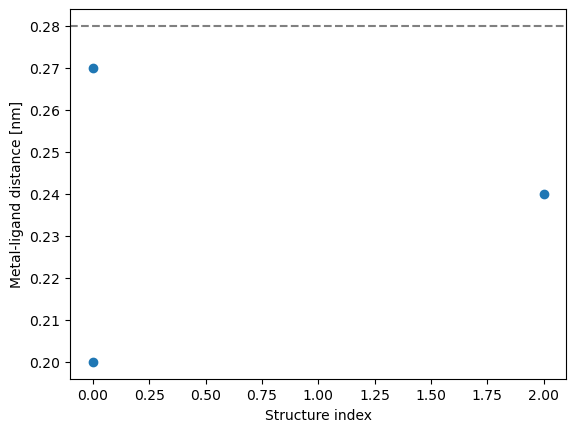

In [4]:
print(analysis.relation(0))
print(analysis.measurements, analysis.measure_units)
import matplotlib.pyplot as plt
plt.scatter(analysis.occurrence_structures, analysis.measurements['distance'])
plt.axhline(.28, color='gray', linestyle='--')
plt.xlabel('Structure index'); plt.ylabel('Metal-ligand distance [nm]'); plt.show()

## Choosing units and cutoffs

The positive scalar cutoff is inclusive, without tolerance. The single default across this metal set is an experimental reference profile, not a universal physical law. All physical input magnitudes need explicit units.

In [5]:
with msm.pyunitwizard.context(standard_units=['angstrom','degrees','ps','e']):
    result = msm.interactions.metal_coordination.get_metal_coordination(molsys, distance_threshold='2.8 angstrom', pbc=False)
print(result.measure_units, result.n_interactions)

{'distance': 'nm'} 3


## Reproducing periodic images

Stored integer shifts multiply box row vectors and add to raw coordinates. Metal anchors the image; selection reversal does not change role order.

In [6]:
periodic = msm.convert(molsys, to_form='molsysmt.MolSys')
shifted = msm.pyunitwizard.get_value(periodic.structures.coordinates, to_unit='nm').copy()
shifted[:,1] += [1,0,0]
periodic.structures.coordinates = msm.pyunitwizard.quantity(shifted, 'nm')
periodic.structures.box = msm.pyunitwizard.quantity(np.repeat(np.eye(3)[None],3,axis=0), 'nm')
observed = msm.interactions.metal_coordination.get_metal_coordination(periodic, structure_indices=[0])
print(observed.image_vectors, observed.measurements['distance'])

[[ 0  0  0]
 [-1  0  0]
 [ 0  0  0]
 [ 0  0  0]] [0.2  0.27]


## Persisting independent analyses

Attachment is explicit. Native and typed forms retain original producer and scientific attribution. See the Cookbook for combined named storage.

In [7]:
typed = msm.interactions.metal_coordination.get_metal_coordination(molsys, pbc=False, output_type='molsysmt.InteractionsDict')
print(msm.convert(typed, to_form='molsysmt.Interactions').n_interactions)
print(analysis.software, analysis.parameters['method_definition'])

3
{'molsysmt': '0.21.0+606.ga03eb4bf6', 'rdkit': '2025.09.5'} molsysmt.metal_coordination.metal_ligand_distance.smarts_metal_ligand@1


## Reading coordinate blocks

Native and H5MSM numeric selections support projected coordinate blocks; accepted sparse output remains in memory. max_matches bounds full-source chemical matching. Rich file selections may need bounded eager loading.

In [8]:
import tempfile
from pathlib import Path
with tempfile.TemporaryDirectory() as folder:
    path = str(Path(folder)/'source.h5msm')
    msm.convert(molsys, to_form=path)
    streamed = msm.interactions.metal_coordination.get_metal_coordination(path, pbc=False, heavy_mode='force', max_matches=1000)
    print(streamed.n_interactions, streamed.execution_records[0]['details']['execution'])

3 chunked


:::{seealso}
:class: dropdown

**Related Tools & References**

- {ref}`Sparse interaction results <user-tools-interactions-result>`
- {func}`molsysmt.Interactions.query` — querying observations by actual atom and structure indices.
:::